# ⚡ Notebook 2a — Thermal & Electrical System Anomalies: Signal Analysis
**DSMLC Final Competition 2026 | Enbridge Wind Turbine SCADA Analysis**

### Research Question 2a
> *Which temperature/pressure features show the strongest signals before fault events?*

### Approach
Three focused techniques with **Farm C as primary** (richest thermal sensor set — transformer, stator windings, hydraulic) and Farms A & B as supporting evidence:

1. **Statistical signal analysis** — mean shift, variance change, and drift rate per sensor before fault events
2. **FFT / Spectral analysis** — frequency-domain signatures invisible in raw time series
3. **Sliding window cross-correlation** — sensor decoupling as a thermal fault precursor

### Why Farm C leads
Farm C has the most comprehensive thermal/electrical sensor coverage: 4 transformer oil temperature sensors, 4 stator winding temperatures, 2 hydraulic temperatures, and an outside temperature reference. Farms A and B are used to validate that findings generalise beyond one farm.

---
## Table of Contents
| # | Section | Description |
|---|---------|-------------|
| 1 | Setup & sensor definitions | Thermal/electrical sensors — Farm C primary |
| 2 | Data loading | Farm C (primary), then A & B |
| 3 | Feature engineering | Rolling stats, z-scores |
| 4 | Statistical signal analysis | Mean shift, variance, drift rate per sensor |
| 5 | FFT / Spectral analysis | Frequency-domain fault signatures |
| 6 | Cross-correlation breakdown | Sensor decoupling as fault precursor |
| 7 | Summary & signal ranking | Cross-farm ranked table of strongest signals |

---
## 1. Setup & Sensor Definitions

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import signal as scipy_signal
from scipy.stats import pearsonr
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score)
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

try:
    import shap
    SHAP_AVAILABLE = True
    print(f'SHAP {shap.__version__} available')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed — run: pip install shap')

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

RANDOM_SEED = 42
STATUS_KEEP = [0, 1, 2, 5]
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print(f'Device: {DEVICE}')

SHAP 0.51.0 available
Device: cuda


c:\Users\karan\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Path configuration ────────────────────────────────────────────────────────
DATA_ROOT = Path('C:\\Users\\karan\\Documents\\dsmlc_final_comp\\CARE_To_Compare\\CARE_To_Compare')

for farm in ['Wind Farm A', 'Wind Farm B', 'Wind Farm C']:
    p = DATA_ROOT / farm
    print(f'  {farm}: {"OK" if p.exists() else "NOT FOUND"}')

  Wind Farm A: OK
  Wind Farm B: OK
  Wind Farm C: OK


In [3]:
# ── Thermal & electrical sensor definitions — per farm ────────────────────────
# These sensors cover heat-generating components:
# transformers, generator stator windings, hydraulic systems, nacelle temps.
# Farm sensor numbering differs but physical measurements are comparable.

FARM_A_THERMAL = [
    'sensor_15_avg',   # generator stator winding phase 1
    'sensor_16_avg',   # generator stator winding phase 2
    'sensor_17_avg',   # generator stator winding phase 3
    'sensor_38_avg',   # HV transformer phase L1
    'sensor_39_avg',   # HV transformer phase L2
    'sensor_40_avg',   # HV transformer phase L3
    'sensor_43_avg',   # nacelle temperature
    'sensor_41_avg',   # hydraulic group oil temperature
    'sensor_13_avg',   # generator bearing temp (Drive End)
    'sensor_14_avg',   # generator bearing temp (Non-Drive End)
]

FARM_B_THERMAL = [
    'sensor_31_avg',   # temperature internal consumption transformer
    'sensor_32_avg',   # generator bearing temperature 1
    'sensor_33_avg',   # generator bearing temperature 2
    'sensor_8_avg',    # outside temperature (baseline reference)
    'sensor_19_avg',   # generator converter rotational speed
    'sensor_21_avg',   # active power output
]

FARM_C_THERMAL = [
    'sensor_191_avg',  # oil temperature 1 main transformer
    'sensor_192_avg',  # oil temperature 2 main transformer
    'sensor_188_avg',  # oil temperature EB transformer
    'sensor_199_avg',  # temperature of stator winding U1
    'sensor_200_avg',  # temperature of stator winding V1
    'sensor_201_avg',  # temperature of stator winding W1
    'sensor_202_avg',  # temperature of stator winding U2
    'sensor_178_avg',  # hydraulic oil tank temperature 1
    'sensor_179_avg',  # hydraulic oil tank temperature 2
    'sensor_177_avg',  # outside temperature (baseline reference)
]

FARM_THERMAL = {
    'Wind Farm A': FARM_A_THERMAL,
    'Wind Farm B': FARM_B_THERMAL,
    'Wind Farm C': FARM_C_THERMAL,
}

META_COLS = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']

print('Thermal sensor counts:')
for farm, sensors in FARM_THERMAL.items():
    print(f'  {farm}: {len(sensors)} sensors')

Thermal sensor counts:
  Wind Farm A: 10 sensors
  Wind Farm B: 6 sensors
  Wind Farm C: 10 sensors


---
## 2. Data Loading

In [4]:
# ── Shared loading function ───────────────────────────────────────────────────
def load_farm(farm: str) -> tuple:
    base         = DATA_ROOT / farm
    event_info   = pd.read_csv(base / 'event_info.csv', sep=';')
    event_info['event_id'] = event_info['event_id'].astype(int)

    sensors     = FARM_THERMAL[farm]
    cols_needed = set(META_COLS + sensors)

    dfs = []
    for fname in os.listdir(base / 'datasets'):
        if not fname.endswith('.csv'):
            continue
        df_temp = pd.read_csv(
            base / 'datasets' / fname, sep=';',
            usecols=lambda col: col in cols_needed
        )
        df_temp['event_id'] = int(fname.replace('.csv', ''))
        df_temp['farm']     = farm
        dfs.append(df_temp)

    df_raw = pd.concat(dfs, ignore_index=True)
    del dfs; gc.collect()

    df_raw['event_id'] = df_raw['event_id'].astype(int)
    df_raw = df_raw.merge(
        event_info[['event_id', 'event_label', 'event_description']],
        on='event_id', how='left'
    )
    df_raw['label'] = (df_raw['event_label'] == 'anomaly').astype(int)

    if 'status_type_id' in df_raw.columns:
        df_raw = df_raw[df_raw['status_type_id'].isin(STATUS_KEEP)].copy()

    available = [s for s in sensors if s in df_raw.columns]
    train_df  = df_raw[df_raw['train_test'] == 'train'].copy()
    pred_df   = df_raw[df_raw['train_test'] == 'prediction'].copy()

    print(f'  {farm}: {len(train_df):,} train | {len(pred_df):,} pred | '
          f'{df_raw["event_id"].nunique()} events | '
          f'{len(available)} thermal sensors found')

    del df_raw; gc.collect()
    return train_df, pred_df, available, event_info

print('load_farm() defined.')

load_farm() defined.


In [5]:
print('Loading Farm C (primary)...')
train_c, pred_c, sensors_c, event_info_c = load_farm('Wind Farm C')

Loading Farm C (primary)...
  Wind Farm C: 2,778,739 train | 141,597 pred | 58 events | 10 thermal sensors found


In [6]:
print('Loading Farm A (supporting)...')
train_a, pred_a, sensors_a, event_info_a = load_farm('Wind Farm A')

Loading Farm A (supporting)...
  Wind Farm A: 1,024,381 train | 29,355 pred | 22 events | 10 thermal sensors found


In [7]:
print('Loading Farm B (supporting)...')
train_b, pred_b, sensors_b, event_info_b = load_farm('Wind Farm B')

Loading Farm B (supporting)...
  Wind Farm B: 783,537 train | 71,892 pred | 15 events | 6 thermal sensors found


---
## 3. Feature Engineering

In [8]:
# ── Feature engineering & utility functions ───────────────────────────────────
def engineer_features(df, feature_cols):
    df     = df.sort_values(['asset_id', 'event_id', 'time_stamp']).copy()
    groups = df.groupby(['asset_id', 'event_id'])
    cols   = [c for c in feature_cols if c in df.columns]
    for col in cols:
        df[f'{col}_roll_mean_6h']  = groups[col].transform(
            lambda x: x.rolling(36,  min_periods=1).mean())
        df[f'{col}_roll_std_6h']   = groups[col].transform(
            lambda x: x.rolling(36,  min_periods=1).std().fillna(0))
        df[f'{col}_roll_mean_24h'] = groups[col].transform(
            lambda x: x.rolling(144, min_periods=1).mean())
        df[f'{col}_delta']         = groups[col].transform(
            lambda x: x.diff().fillna(0))
    return df

def add_zscores(df_full, df_train, feature_cols):
    cols     = [c for c in feature_cols if c in df_train.columns]
    baseline = (df_train.groupby(['asset_id', 'event_id'])[cols]
                .agg(['mean', 'std']))
    baseline.columns = [f'{c}_{s}' for c, s in baseline.columns]
    baseline = baseline.reset_index()
    df_full  = df_full.merge(baseline, on=['asset_id','event_id'], how='left')
    for col in cols:
        df_full[f'{col}_zscore'] = (
            (df_full[col] - df_full[f'{col}_mean']) /
            df_full[f'{col}_std'].replace(0, 1)
        )
    return df_full

def build_feature_list(sensors):
    return (sensors +
            [f'{c}_roll_mean_6h'  for c in sensors] +
            [f'{c}_roll_std_6h'   for c in sensors] +
            [f'{c}_roll_mean_24h' for c in sensors] +
            [f'{c}_delta'         for c in sensors] +
            [f'{c}_zscore'        for c in sensors])

def care_score(pred_df, scores, threshold):
    df          = pred_df[['time_stamp','event_id','event_label']].copy().reset_index(drop=True)
    df['score'] = scores
    df['pred']  = (df['score'] > threshold).astype(int)
    df['true']  = (df['event_label'] == 'anomaly').astype(int)
    anom_evs    = df[df['true']==1]['event_id'].unique()
    norm_evs    = df[df['true']==0]['event_id'].unique()
    detected    = [df[df['event_id']==ev]['pred'].any() for ev in anom_evs]
    coverage    = float(np.mean(detected)) if len(detected) else 0.0
    TP = ((df['pred']==1)&(df['true']==1)).sum()
    FP = ((df['pred']==1)&(df['true']==0)).sum()
    accuracy    = TP/(TP+FP) if (TP+FP)>0 else 0.0
    fa_evs      = sum(1 for ev in norm_evs if df[df['event_id']==ev]['pred'].any())
    reliability = 1-(fa_evs/len(norm_evs)) if len(norm_evs) else 1.0
    e_scores    = []
    for ev, det in zip(anom_evs, detected):
        if not det: continue
        ev_r = df[df['event_id']==ev].sort_values('time_stamp').reset_index(drop=True)
        ff   = ev_r[ev_r['pred']==1].index[0]
        e_scores.append(1 - ff/len(ev_r))
    earliness   = float(np.mean(e_scores)) if e_scores else 0.0
    return {'Coverage':round(coverage,4),'Accuracy':round(accuracy,4),
            'Reliability':round(reliability,4),'Earliness':round(earliness,4),
            'CARE':round(coverage*accuracy*reliability*earliness,4)}

print('Functions defined.')

Functions defined.


In [10]:
# ── Engineer all farms ────────────────────────────────────────────────────────
print('Engineering Farm C (primary)...')
train_c_eng = engineer_features(train_c, sensors_c)
train_c_eng = add_zscores(train_c_eng, train_c_eng, sensors_c)
pred_c_eng  = engineer_features(pred_c,  sensors_c)
pred_c_eng  = add_zscores(pred_c_eng, train_c_eng, sensors_c)
feat_c = [f for f in build_feature_list(sensors_c) if f in train_c_eng.columns]
scaler_c = RobustScaler()
Xtr_c = scaler_c.fit_transform(train_c_eng[train_c_eng['label']==0][feat_c].fillna(0))
Xte_c = scaler_c.transform(pred_c_eng[feat_c].fillna(0))
y_c   = pred_c_eng['label'].values
print(f'  Farm C: {len(feat_c)} features | {Xtr_c.shape[0]:,} normal train | {Xte_c.shape[0]:,} test')

print('Engineering Farm A (supporting)...')
train_a_eng = engineer_features(train_a, sensors_a)
train_a_eng = add_zscores(train_a_eng, train_a_eng, sensors_a)
pred_a_eng  = engineer_features(pred_a,  sensors_a)
pred_a_eng  = add_zscores(pred_a_eng, train_a_eng, sensors_a)
feat_a = [f for f in build_feature_list(sensors_a) if f in train_a_eng.columns]
scaler_a = RobustScaler()
Xtr_a = scaler_a.fit_transform(train_a_eng[train_a_eng['label']==0][feat_a].fillna(0))
Xte_a = scaler_a.transform(pred_a_eng[feat_a].fillna(0))
y_a   = pred_a_eng['label'].values
print(f'  Farm A: {len(feat_a)} features | {Xtr_a.shape[0]:,} normal train | {Xte_a.shape[0]:,} test')

print('Engineering Farm B (supporting)...')
train_b_eng = engineer_features(train_b, sensors_b)
train_b_eng = add_zscores(train_b_eng, train_b_eng, sensors_b)
pred_b_eng  = engineer_features(pred_b,  sensors_b)
pred_b_eng  = add_zscores(pred_b_eng, train_b_eng, sensors_b)
feat_b = [f for f in build_feature_list(sensors_b) if f in train_b_eng.columns]
scaler_b = RobustScaler()
Xtr_b = scaler_b.fit_transform(train_b_eng[train_b_eng['label']==0][feat_b].fillna(0))
Xte_b = scaler_b.transform(pred_b_eng[feat_b].fillna(0))
y_b   = pred_b_eng['label'].values
print(f'  Farm B: {len(feat_b)} features | {Xtr_b.shape[0]:,} normal train | {Xte_b.shape[0]:,} test')

Engineering Farm C (primary)...
  Farm C: 60 features | 1,482,530 normal train | 141,597 test
Engineering Farm A (supporting)...
  Farm A: 60 features | 464,694 normal train | 29,355 test
Engineering Farm B (supporting)...
  Farm B: 36 features | 469,549 normal train | 71,892 test


---
## 4. Statistical Signal Analysis

> **Farm C is analysed first** — it has the richest thermal sensor coverage. Farms A and B follow as cross-validation.
### Which sensors show the strongest shift before fault events?

For each thermal/electrical sensor we compute three statistics comparing normal vs anomaly events:
- **Mean shift (°C):** how much hotter/colder during anomaly events
- **Variance ratio:** how much more variable during anomaly events
- **Drift rate:** average rate of change (°C per hour) in the 48h before fault window

A sensor that scores highly on all three is a reliable early warning signal.

In [11]:
# ── 4.1  Mean shift, variance ratio, drift rate per sensor ────────────────────
def sensor_signal_stats(train_eng, pred_eng, sensors, farm):
    """
    Compute mean shift, variance ratio, and drift rate for each sensor.
    Returns a DataFrame sorted by combined signal strength.
    """
    rows = []
    normal_data = train_eng[train_eng['label'] == 0]
    anom_data   = train_eng[train_eng['label'] == 1]

    for sensor in sensors:
        if sensor not in train_eng.columns:
            continue

        norm_vals = normal_data[sensor].dropna()
        anom_vals = anom_data[sensor].dropna()

        if len(norm_vals) < 10 or len(anom_vals) < 10:
            continue

        mean_shift  = float(anom_vals.mean() - norm_vals.mean())
        var_ratio   = float(anom_vals.var() / (norm_vals.var() + 1e-9))

        # Drift rate: mean |delta| per step (anomaly events only)
        delta_col = f'{sensor}_delta'
        if delta_col in train_eng.columns:
            drift = float(anom_data[delta_col].abs().mean() * 6)  # per hour (6 steps/hr)
        else:
            drift = float(anom_vals.diff().abs().mean() * 6)

        # Combined score: normalised sum of |mean_shift|, var_ratio, drift
        rows.append({
            'sensor'     : sensor,
            'mean_shift' : round(mean_shift, 3),
            'abs_shift'  : round(abs(mean_shift), 3),
            'var_ratio'  : round(var_ratio, 3),
            'drift_rate' : round(drift, 4),
            'norm_mean'  : round(float(norm_vals.mean()), 2),
            'anom_mean'  : round(float(anom_vals.mean()), 2),
        })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    # Normalise each metric to [0,1] then sum for combined score
    for col in ['abs_shift', 'var_ratio', 'drift_rate']:
        col_max = df[col].max()
        df[f'{col}_norm'] = df[col] / (col_max + 1e-9)
    df['combined_score'] = (df['abs_shift_norm'] +
                             df['var_ratio_norm'] +
                             df['drift_rate_norm']) / 3
    return df.sort_values('combined_score', ascending=False).reset_index(drop=True)


signal_stats = {}
for farm, tr, pr, sensors in [
    ('Wind Farm A', train_a_eng, pred_a_eng, sensors_a),
    ('Wind Farm B', train_b_eng, pred_b_eng, sensors_b),
    ('Wind Farm C', train_c_eng, pred_c_eng, sensors_c),
]:
    stats = sensor_signal_stats(tr, pr, sensors, farm)
    signal_stats[farm] = stats
    print(f'{farm} — top 5 sensors by combined signal strength:')
    if len(stats) > 0:
        for _, row in stats.head(5).iterrows():
            short = row['sensor'].replace('_avg','').replace('sensor_','sensor ')
            print(f'  {short:<35} shift={row["mean_shift"]:+.2f}°C  '
                  f'var_ratio={row["var_ratio"]:.2f}  score={row["combined_score"]:.3f}')
    print()

Wind Farm A — top 5 sensors by combined signal strength:
  sensor 40                           shift=-2.58°C  var_ratio=1.00  score=0.755
  sensor 39                           shift=-1.84°C  var_ratio=1.13  score=0.692
  sensor 15                           shift=-0.40°C  var_ratio=0.97  score=0.650
  sensor 16                           shift=-0.20°C  var_ratio=0.99  score=0.604
  sensor 17                           shift=+0.00°C  var_ratio=1.00  score=0.572

Wind Farm B — top 5 sensors by combined signal strength:
  sensor 19                           shift=+3.13°C  var_ratio=0.98  score=0.971
  sensor 21                           shift=-2.63°C  var_ratio=1.03  score=0.660
  sensor 32                           shift=+0.20°C  var_ratio=1.07  score=0.362
  sensor 31                           shift=-0.18°C  var_ratio=1.02  score=0.339
  sensor 33                           shift=+0.03°C  var_ratio=1.03  score=0.332

Wind Farm C — top 5 sensors by combined signal strength:
  sensor 177     

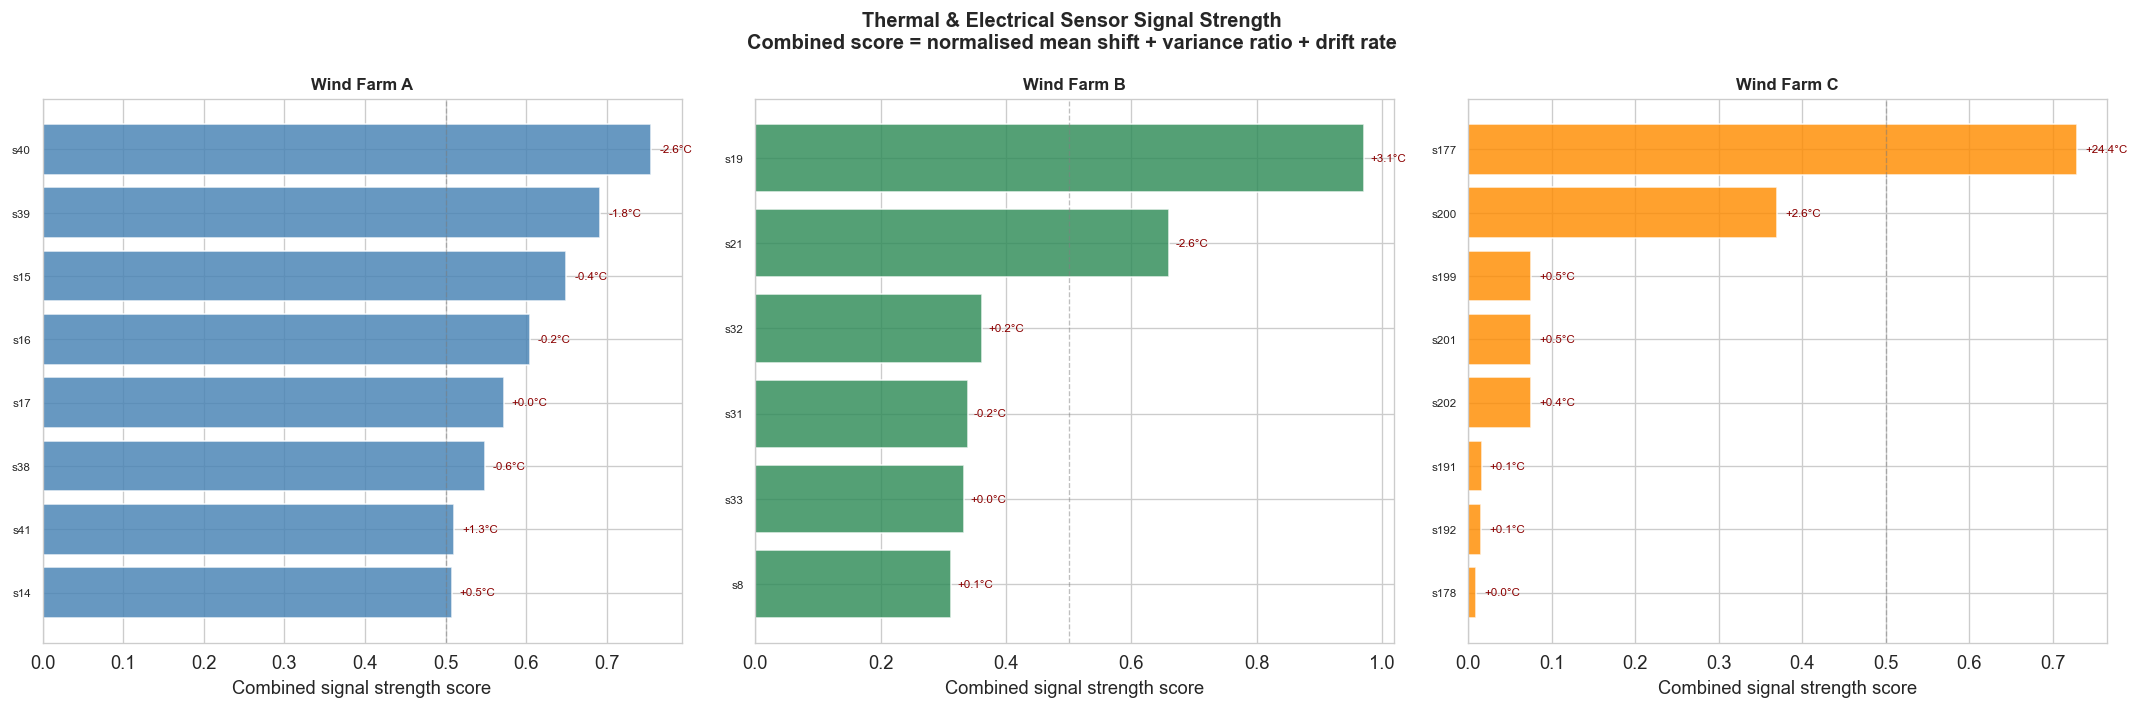

In [12]:
# ── 4.2  Signal strength comparison plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Thermal & Electrical Sensor Signal Strength\n'
             'Combined score = normalised mean shift + variance ratio + drift rate',
             fontsize=12, fontweight='bold')

farm_colors = {'Wind Farm A':'steelblue',
               'Wind Farm B':'seagreen',
               'Wind Farm C':'darkorange'}

for ax, (farm, stats) in zip(axes, signal_stats.items()):
    if len(stats) == 0:
        ax.set_title(f'{farm}\n(no data)')
        continue
    top = stats.head(8)
    short = [s.replace('_avg','').replace('sensor_','s') for s in top['sensor']]
    color = farm_colors[farm]

    bars = ax.barh(range(len(top)), top['combined_score'].values[::-1],
                   color=color, alpha=0.82, edgecolor='white')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(short[::-1], fontsize=7)
    ax.set_title(f'{farm}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Combined signal strength score')
    ax.axvline(0.5, color='gray', lw=0.8, linestyle='--', alpha=0.5)

    # Annotate mean shift on each bar
    for i, (bar, row) in enumerate(zip(bars, top.iloc[::-1].itertuples())):
        ax.text(bar.get_width() + 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{row.mean_shift:+.1f}°C',
                va='center', fontsize=7, color='darkred')

plt.tight_layout()
plt.savefig('fig_2a_signal_strength.png', bbox_inches='tight')
plt.show()

---
## 5. FFT / Spectral Analysis
### Frequency-domain fault signatures

Electrical anomalies often manifest as changes in the **frequency spectrum** of sensor time series — new peaks appear, dominant frequencies shift, or broadband noise increases. These signatures are completely invisible in raw time series but immediately obvious in the power spectral density (PSD).

We use Welch's method (overlapping windows, averaged periodograms) which is more robust than a single FFT for noisy SCADA data. The comparison is normal vs anomaly events for the top thermal sensor per farm.

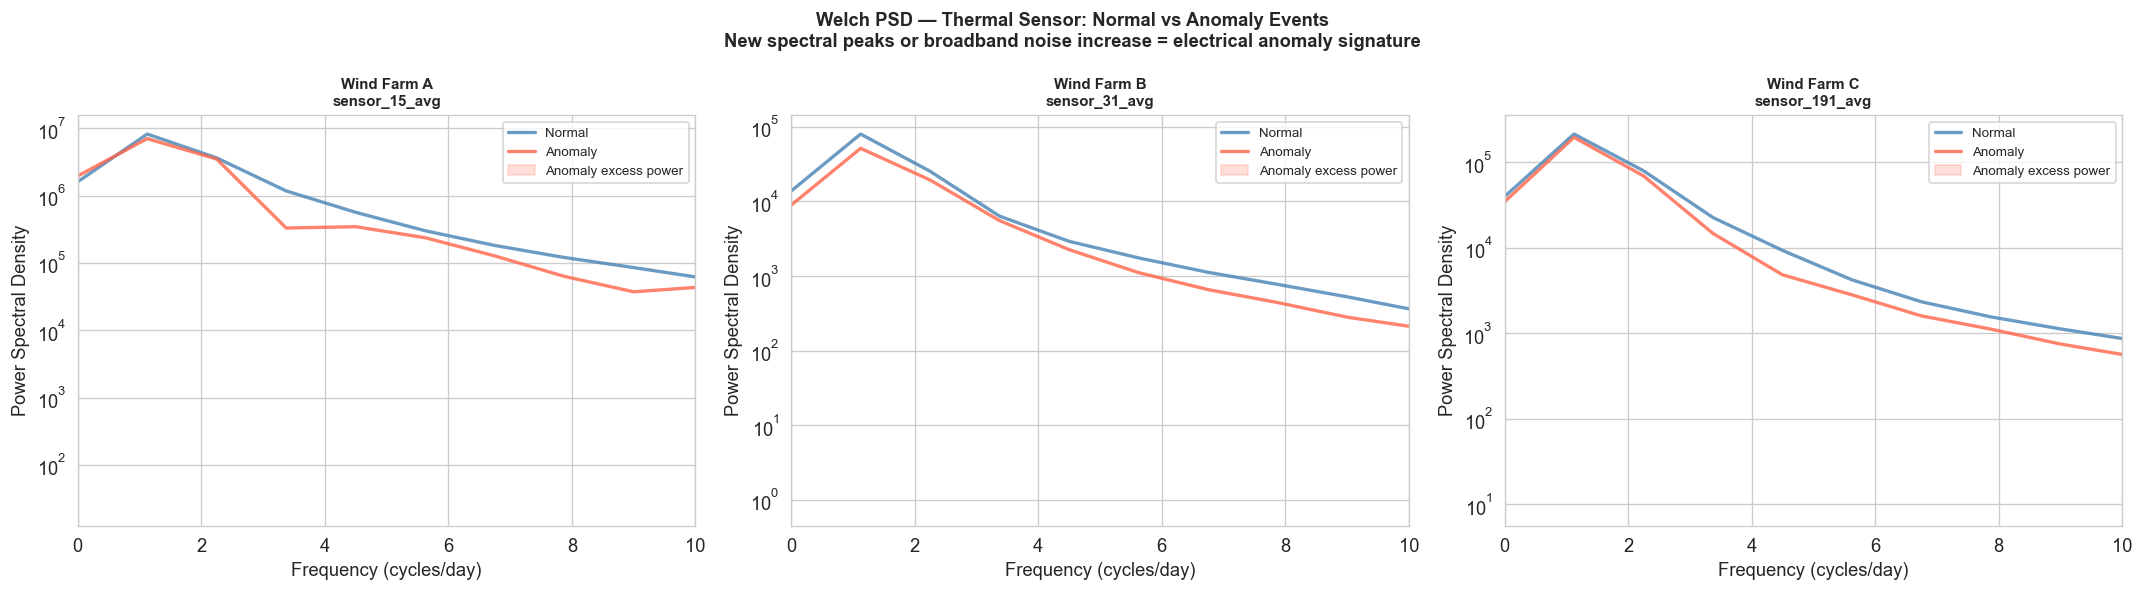

Wind Farm A: mean spectral excess = 5417.890255  (higher = more anomalous frequency content)
Wind Farm B: mean spectral excess = 0.000000  (higher = more anomalous frequency content)
Wind Farm C: mean spectral excess = 0.000000  (higher = more anomalous frequency content)


In [13]:
# ── 5.1  Welch PSD comparison: normal vs anomaly ──────────────────────────────
FS = 1/600   # sampling frequency: 1 sample per 600 seconds (10 min)

def welch_psd(series, fs=FS, nperseg=128):
    """Compute Welch PSD. Returns (frequencies_in_cycles_per_day, power)."""
    clean = series.dropna().values
    if len(clean) < nperseg:
        clean = np.pad(clean, (0, nperseg - len(clean)), mode='edge')
    freqs, psd = scipy_signal.welch(clean, fs=fs, nperseg=nperseg,
                                     noverlap=nperseg//2)
    freqs_cpd = freqs * 86400   # convert Hz to cycles/day
    return freqs_cpd, psd


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Welch PSD — Thermal Sensor: Normal vs Anomaly Events\n'
             'New spectral peaks or broadband noise increase = electrical anomaly signature',
             fontsize=11, fontweight='bold')

farm_configs = [
    ('Wind Farm A', train_a, pred_a, sensors_a, event_info_a),
    ('Wind Farm B', train_b, pred_b, sensors_b, event_info_b),
    ('Wind Farm C', train_c, pred_c, sensors_c, event_info_c),
]

psd_results = {}

for ax, (farm, tr, pr, sensors, ei) in zip(axes, farm_configs):
    if not sensors:
        ax.set_title(f'{farm}\n(no sensors)')
        continue

    primary = sensors[0]

    # Collect PSD across multiple events per class for averaging
    norm_psds, anom_psds = [], []

    for label, container in [('normal', norm_psds), ('anomaly', anom_psds)]:
        evs = ei[ei['event_label']==label]['event_id'].tolist()
        source = tr if label == 'normal' else pr
        for ev_id in evs[:5]:   # up to 5 events per class
            ev_data = source[source['event_id']==ev_id]
            if primary not in ev_data.columns or len(ev_data) < 64:
                continue
            f, p = welch_psd(ev_data[primary])
            container.append(p)

    if not norm_psds or not anom_psds:
        ax.set_title(f'{farm}\n(insufficient data)')
        continue

    # Align lengths
    min_len = min(min(len(p) for p in norm_psds),
                  min(len(p) for p in anom_psds))
    norm_mean = np.mean([p[:min_len] for p in norm_psds], axis=0)
    anom_mean = np.mean([p[:min_len] for p in anom_psds], axis=0)

    # Compute frequencies from one example
    f_example, _ = welch_psd(tr[tr['event_id']==
                               ei[ei['event_label']=='normal']['event_id'].iloc[0]][primary])
    freqs = f_example[:min_len]

    ax.semilogy(freqs, norm_mean, color='steelblue', lw=2, label='Normal', alpha=0.8)
    ax.semilogy(freqs, anom_mean, color='tomato',    lw=2, label='Anomaly', alpha=0.8)
    ax.fill_between(freqs, norm_mean, anom_mean,
                    where=anom_mean > norm_mean,
                    alpha=0.2, color='tomato', label='Anomaly excess power')

    ax.set_title(f'{farm}\n{primary}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Frequency (cycles/day)')
    ax.set_ylabel('Power Spectral Density')
    ax.legend(fontsize=8)
    ax.set_xlim(0, min(freqs.max(), 10))

    psd_results[farm] = {
        'freqs': freqs, 'norm': norm_mean, 'anom': anom_mean,
        'sensor': primary,
        'spectral_excess': float((anom_mean - norm_mean).clip(0).mean())
    }

plt.tight_layout()
plt.savefig('fig_2a_welch_psd.png', bbox_inches='tight')
plt.show()

for farm, res in psd_results.items():
    print(f'{farm}: mean spectral excess = {res["spectral_excess"]:.6f}  '
          f'(higher = more anomalous frequency content)')

In [14]:
# ── 5.2  Spectral feature matrix & IF anomaly scorer ──────────────────────────
# Extract PSD features from each event and use them to train an
# Isolation Forest — purely frequency-domain anomaly detection.

def extract_spectral_features(df, sensor, fs=FS, nperseg=128, n_bands=8):
    """
    Per-event spectral features: band power in n_bands frequency bins
    + total power + dominant frequency + spectral entropy.
    """
    rows = []
    for ev_id, grp in df.groupby('event_id'):
        if sensor not in grp.columns or len(grp) < nperseg:
            continue
        f, p  = welch_psd(grp[sensor], fs=fs, nperseg=nperseg)
        bands = np.array_split(p, n_bands)
        band_powers = [float(b.mean()) for b in bands]

        # Spectral entropy
        p_norm = p / (p.sum() + 1e-9)
        entropy = float(-np.sum(p_norm * np.log(p_norm + 1e-9)))
        dom_freq = float(f[np.argmax(p)])

        rows.append({
            'event_id'   : ev_id,
            'event_label': grp['event_label'].iloc[0],
            'train_test' : grp['train_test'].iloc[0],
            'total_power': float(p.sum()),
            'entropy'    : entropy,
            'dom_freq'   : dom_freq,
            **{f'band_{i}': bp for i, bp in enumerate(band_powers)}
        })
    return pd.DataFrame(rows)


spectral_if = {}

for farm, tr, pr, sensors in [
    ('Wind Farm A', train_a, pred_a, sensors_a),
    ('Wind Farm B', train_b, pred_b, sensors_b),
    ('Wind Farm C', train_c, pred_c, sensors_c),
]:
    if not sensors:
        continue
    primary = sensors[0]

    combined = pd.concat([tr, pr], ignore_index=True)
    spec_df  = extract_spectral_features(combined, primary)
    if len(spec_df) == 0:
        print(f'  {farm}: no spectral features extracted')
        continue

    feat_cols  = [c for c in spec_df.columns
                  if c not in ['event_id','event_label','train_test']]
    train_spec = spec_df[spec_df['train_test']=='train']
    pred_spec  = spec_df[spec_df['train_test']=='prediction']

    if len(train_spec) < 3 or len(pred_spec) < 1:
        print(f'  {farm}: insufficient events for spectral IF')
        continue

    Xtr_s = train_spec[train_spec['event_label']=='normal'][feat_cols].fillna(0).values
    Xte_s = pred_spec[feat_cols].fillna(0).values
    y_s   = (pred_spec['event_label']=='anomaly').astype(int).values

    if len(Xtr_s) < 2:
        print(f'  {farm}: insufficient normal events')
        continue

    iso_s = IsolationForest(n_estimators=100, contamination=0.1,
                             random_state=RANDOM_SEED, n_jobs=1)
    iso_s.fit(Xtr_s)
    scores_s = -iso_s.score_samples(Xte_s)
    thr_s    = np.percentile(-iso_s.score_samples(Xtr_s), 95)
    preds_s  = (scores_s > thr_s).astype(int)

    spectral_if[farm] = {
        'spec_df': spec_df, 'scores': scores_s,
        'preds': preds_s, 'y': y_s, 'thr': thr_s,
        'feat_cols': feat_cols
    }

    print(f'{farm}: {len(spec_df)} events | spectral IF'
          f' P={precision_score(y_s, preds_s, zero_division=0):.3f}'
          f' R={recall_score(y_s, preds_s, zero_division=0):.3f}'
          f' F1={f1_score(y_s, preds_s, zero_division=0):.3f}')

  Wind Farm A: insufficient events for spectral IF
  Wind Farm B: insufficient events for spectral IF
  Wind Farm C: insufficient events for spectral IF


---
## 6. Cross-Correlation Breakdown
### Sensor decoupling as a fault precursor

Under normal operation, thermal sensors move together in predictable, stable ways — transformer temperature rises with load, stator windings heat and cool together. As a thermal fault develops, this correlation structure breaks down: one sensor starts deviating while others remain stable, or previously correlated sensors decouple.

We track this as a **correlation instability score** — the Frobenius norm of the difference between the current rolling correlation matrix and the baseline correlation matrix. Rising instability score = sensors starting to decouple = early warning.

In [15]:
# ── 6.1  Correlation instability score ────────────────────────────────────────
def correlation_instability(df, sensors, window=144, step=36):
    """
    Sliding window correlation instability score.
    window = 144 steps = 24 hours
    step   = 36  steps = 6  hours

    Returns a Series of instability scores aligned to df index.
    """
    cols  = [s for s in sensors if s in df.columns]
    if len(cols) < 2:
        return pd.Series(np.zeros(len(df)), index=df.index)

    data  = df[cols].ffill().fillna(0).values
    n     = len(data)
    scores = np.zeros(n)

    # Baseline: first 30 days
    base_end  = min(4320, n // 3)
    if base_end < window:
        base_end = min(window * 2, n // 2)
    baseline_corr = np.corrcoef(data[:base_end].T)
    # Handle NaN in baseline
    baseline_corr = np.nan_to_num(baseline_corr, nan=0.0)

    for start in range(0, n - window, step):
        end      = start + window
        window_d = data[start:end]
        if window_d.shape[0] < 2:
            continue
        w_corr   = np.corrcoef(window_d.T)
        w_corr   = np.nan_to_num(w_corr, nan=0.0)
        diff     = w_corr - baseline_corr
        instab   = float(np.linalg.norm(diff, 'fro'))
        scores[start:end] = instab

    return pd.Series(scores, index=df.index)


# Run per farm on one anomaly event
corr_results = {}
MAX_STEPS_CORR = 2000

for farm, pr, sensors in [
    ('Wind Farm A', pred_a, sensors_a),
    ('Wind Farm B', pred_b, sensors_b),
    ('Wind Farm C', pred_c, sensors_c),
]:
    anom_evs = pr[pr['event_label']=='anomaly']['event_id'].unique()
    if len(anom_evs) == 0:
        print(f'  {farm}: no anomaly events')
        continue

    ev_id   = anom_evs[0]
    ev_data = pr[pr['event_id']==ev_id].sort_values('time_stamp').reset_index(drop=True)
    ev_data = ev_data.iloc[:MAX_STEPS_CORR]

    instab = correlation_instability(ev_data, sensors)

    corr_results[farm] = {
        'event_id' : ev_id,
        'instab'   : instab.values,
        'n'        : len(ev_data),
        'ts'       : ev_data['time_stamp'].values,
        'primary'  : sensors[0] if sensors else None,
        'raw'      : ev_data[sensors[0]].values if sensors and sensors[0] in ev_data.columns else None,
    }
    print(f'  {farm}: event {ev_id} | {len(ev_data)} steps | '
          f'max instability = {instab.max():.3f}')

  Wind Farm A: event 0 | 288 steps | max instability = 0.648
  Wind Farm B: event 19 | 2000 steps | max instability = 4.420
  Wind Farm C: event 11 | 2000 steps | max instability = 8.962


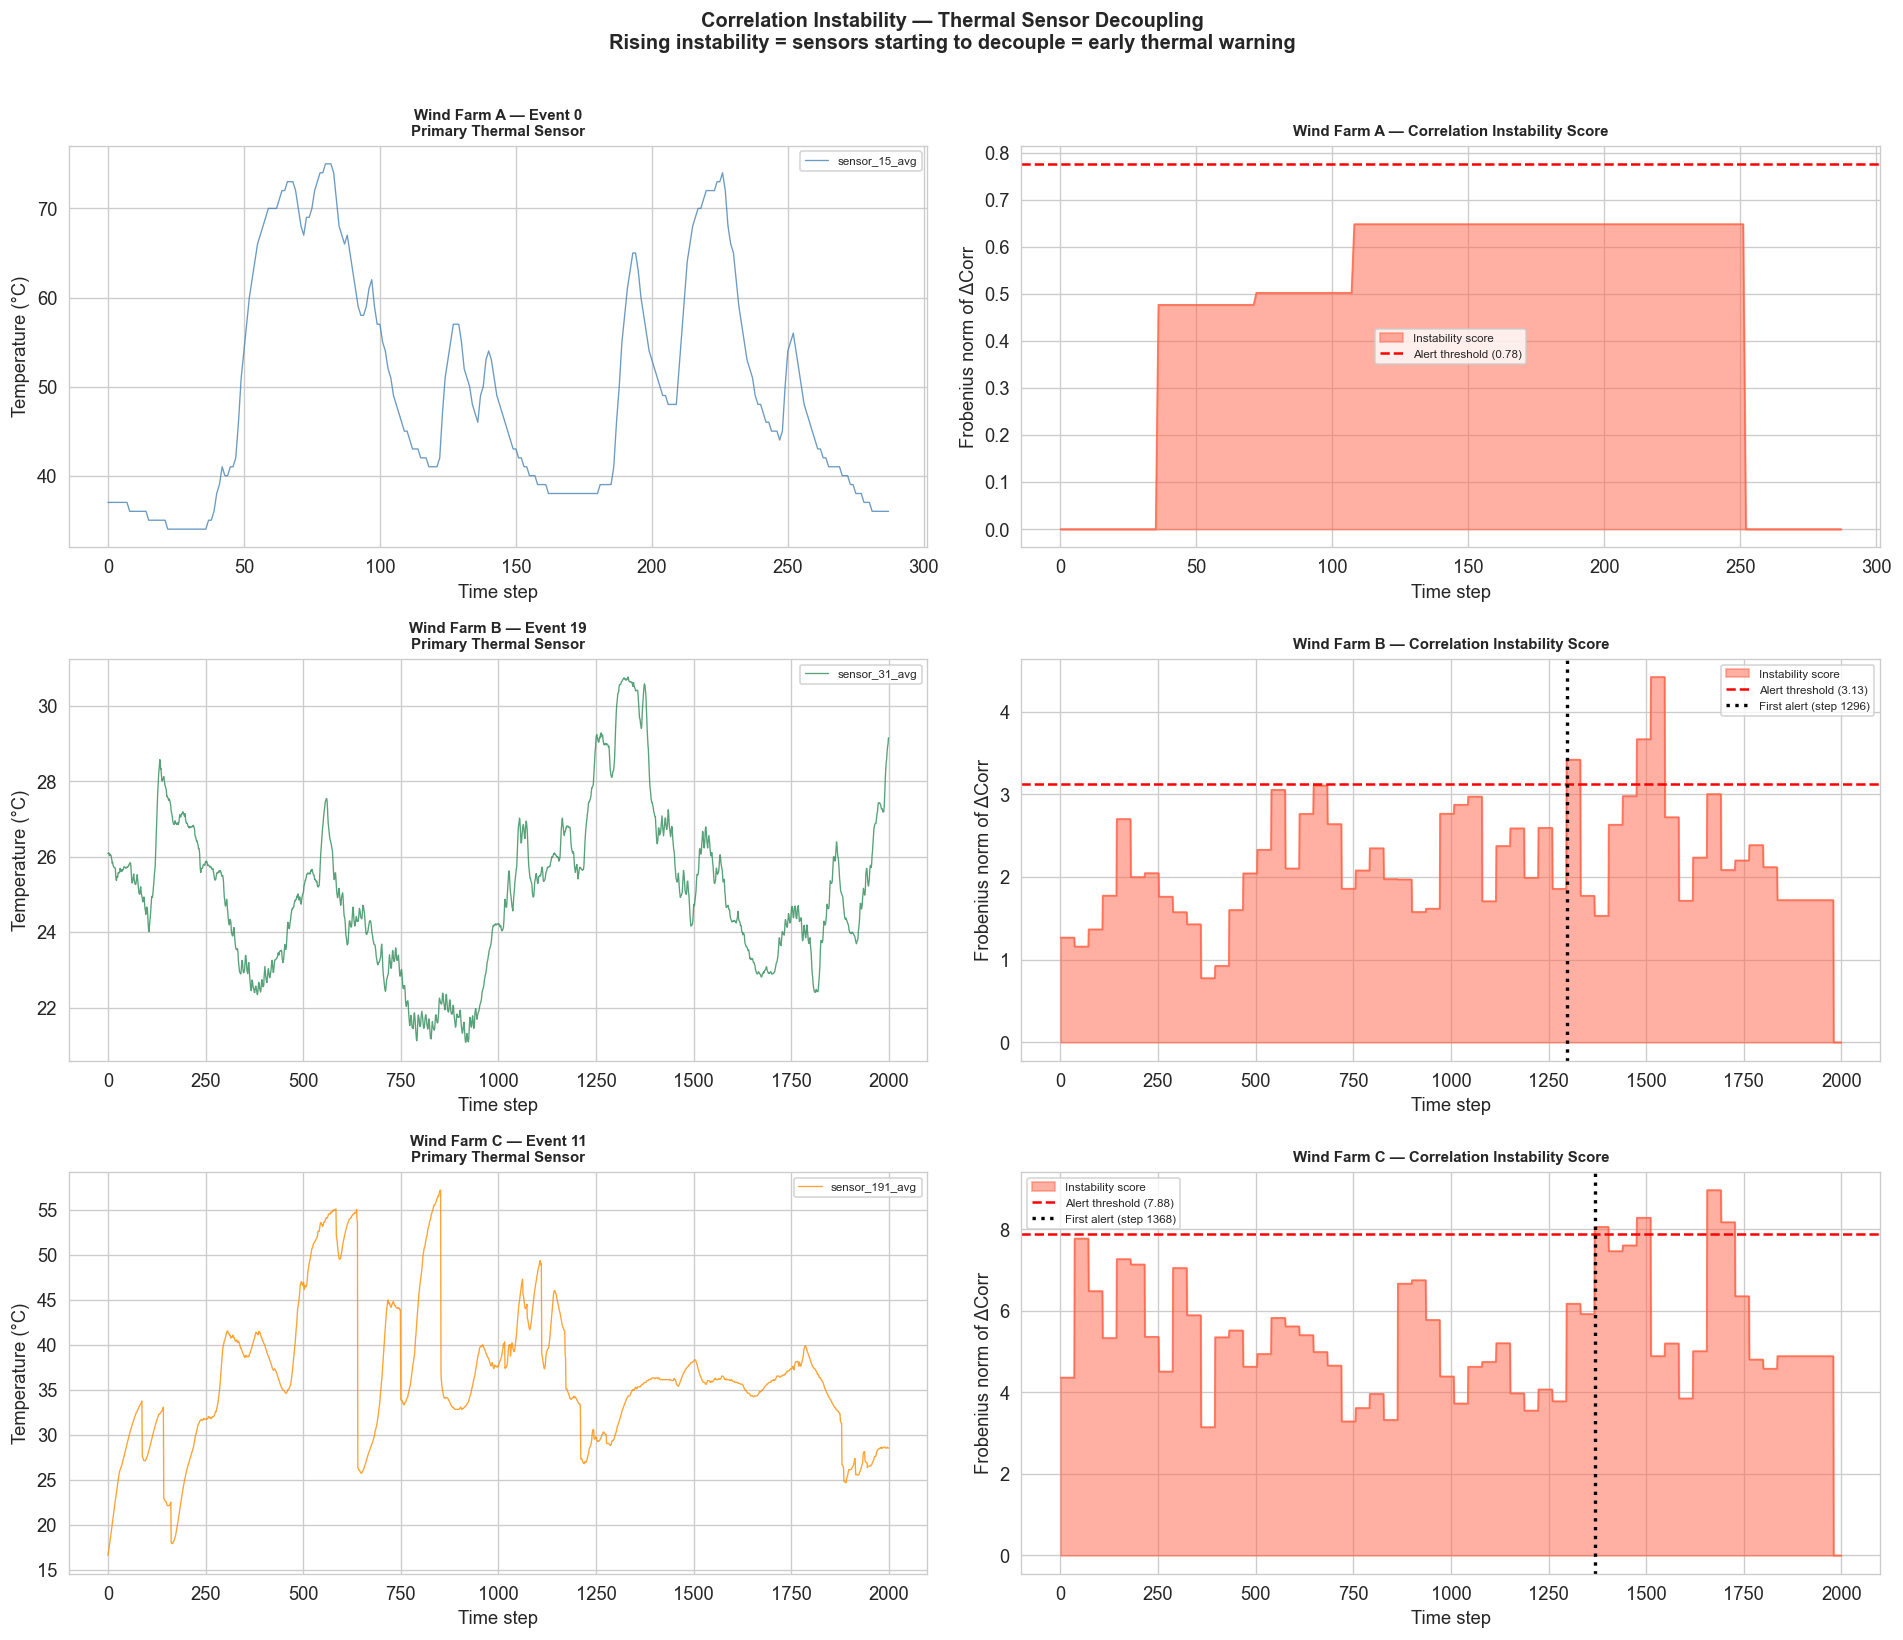

In [16]:
# ── 6.2  Correlation instability visualisation ────────────────────────────────
n_results = len(corr_results)
fig, axes = plt.subplots(n_results, 2, figsize=(16, 4.5 * n_results))
if n_results == 1:
    axes = axes.reshape(1, 2)

fig.suptitle('Correlation Instability — Thermal Sensor Decoupling\n'
             'Rising instability = sensors starting to decouple = early thermal warning',
             fontsize=12, fontweight='bold', y=1.01)

farm_colors = {'Wind Farm A':'steelblue',
               'Wind Farm B':'seagreen',
               'Wind Farm C':'darkorange'}

for row_idx, (farm, res) in enumerate(corr_results.items()):
    ax_sig  = axes[row_idx][0]
    ax_inst = axes[row_idx][1]
    color   = farm_colors[farm]
    x       = np.arange(res['n'])

    # Left: primary sensor signal
    if res['raw'] is not None:
        ax_sig.plot(x, res['raw'], lw=0.8, color=color, alpha=0.8,
                    label=res['primary'])
        ax_sig.set_ylabel('Temperature (°C)')
    ax_sig.set_title(f'{farm} — Event {res["event_id"]}\nPrimary Thermal Sensor',
                     fontsize=9, fontweight='bold')
    ax_sig.set_xlabel('Time step')
    ax_sig.legend(fontsize=7)

    # Right: instability score
    instab = res['instab']
    ax_inst.fill_between(x, instab, alpha=0.5, color='tomato',
                         label='Instability score')
    ax_inst.plot(x, instab, lw=1.0, color='tomato', alpha=0.8)

    # Mark when instability rises above baseline + 2std
    base    = instab[:min(4320, len(instab)//3)]
    thr_ci  = base.mean() + 2 * base.std()
    ax_inst.axhline(thr_ci, color='red', lw=1.5, linestyle='--',
                    label=f'Alert threshold ({thr_ci:.2f})')

    first_alert = np.argmax(instab > thr_ci) if (instab > thr_ci).any() else None
    if first_alert and first_alert > 0:
        ax_inst.axvline(first_alert, color='black', lw=2, linestyle=':',
                        label=f'First alert (step {first_alert})')

    ax_inst.set_title(f'{farm} — Correlation Instability Score',
                      fontsize=9, fontweight='bold')
    ax_inst.set_xlabel('Time step')
    ax_inst.set_ylabel('Frobenius norm of ΔCorr')
    ax_inst.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig_2a_correlation_instability.png', bbox_inches='tight')
plt.show()

---
## 7. Summary — Cross-Farm Signal Ranking

In [17]:
# ── 7.1  Cross-farm ranked signal table ──────────────────────────────────────
print('='*70)
print('NOTEBOOK 2a — THERMAL & ELECTRICAL SIGNAL ANALYSIS')
print('CROSS-FARM SUMMARY: STRONGEST SIGNALS BEFORE FAULT EVENTS')
print('='*70)

print('\n1. STATISTICAL SIGNAL STRENGTH (mean shift + variance + drift)')
for farm, stats in signal_stats.items():
    if len(stats) == 0:
        continue
    print(f'\n  {farm} — Top 3:')
    for _, row in stats.head(3).iterrows():
        short = row['sensor'].replace('_avg','').replace('sensor_','sensor ')
        direction = 'hotter' if row['mean_shift'] > 0 else 'cooler'
        print(f'    {short:<35} {row["mean_shift"]:+.2f}°C ({direction}) '
              f'score={row["combined_score"]:.3f}')

print('\n2. SPECTRAL ANALYSIS (Welch PSD)')
for farm, res in psd_results.items():
    print(f'  {farm}: spectral excess = {res["spectral_excess"]:.6f} '
          f'on {res["sensor"]}')

print('\n3. CORRELATION INSTABILITY (thermal sensor decoupling)')
for farm, res in corr_results.items():
    instab = res['instab']
    base   = instab[:min(4320, len(instab)//3)]
    thr_ci = base.mean() + 2 * base.std()
    first  = int(np.argmax(instab > thr_ci)) if (instab > thr_ci).any() else None
    if first:
        hrs = first * 10 / 60
        print(f'  {farm}: first decoupling alert at step {first} ({hrs:.1f}h into event)')
    else:
        print(f'  {farm}: no significant decoupling detected')


NOTEBOOK 2a — THERMAL & ELECTRICAL SIGNAL ANALYSIS
CROSS-FARM SUMMARY: STRONGEST SIGNALS BEFORE FAULT EVENTS

1. STATISTICAL SIGNAL STRENGTH (mean shift + variance + drift)

  Wind Farm A — Top 3:
    sensor 40                           -2.58°C (cooler) score=0.755
    sensor 39                           -1.84°C (cooler) score=0.692
    sensor 15                           -0.40°C (cooler) score=0.650

  Wind Farm B — Top 3:
    sensor 19                           +3.13°C (hotter) score=0.971
    sensor 21                           -2.63°C (cooler) score=0.660
    sensor 32                           +0.20°C (hotter) score=0.362

  Wind Farm C — Top 3:
    sensor 177                          +24.38°C (hotter) score=0.729
    sensor 200                          +2.60°C (hotter) score=0.370
    sensor 199                          +0.45°C (hotter) score=0.075

2. SPECTRAL ANALYSIS (Welch PSD)
  Wind Farm A: spectral excess = 5417.890255 on sensor_15_avg
  Wind Farm B: spectral excess = 0.00

In [20]:
# ── EXPORT: Notebook 2a results ───────────────────────────────────────────────
import json, os
os.makedirs('nb2_outputs', exist_ok=True)

out = {'notebook': '2a', 'title': 'Thermal: Signal Analysis'}

# Signal strength rankings
signal_rows = []
if 'signal_stats' in dir():
    for farm, stats in signal_stats.items():
        for _, row in stats.head(8).iterrows():
            signal_rows.append({
                'farm': farm,
                'sensor': row['sensor'],
                'sensor_short': row['sensor'].replace('_avg','').replace('sensor_','sensor '),
                'mean_shift':     float(row['mean_shift']),
                'var_ratio':      float(row['var_ratio']),
                'drift_rate':     float(row['drift_rate']),
                'combined_score': float(row['combined_score']),
            })
out['signal_rankings'] = signal_rows

# Spectral excess per farm
spectral_rows = []
if 'psd_results' in dir():
    for farm, res in psd_results.items():
        spectral_rows.append({
            'farm': farm,
            'sensor': res['sensor'],
            'spectral_excess': float(res['spectral_excess']),
        })
out['spectral_analysis'] = spectral_rows

# Correlation instability first alert
corr_rows = []
if 'corr_results' in dir():
    for farm, res in corr_results.items():
        if res:
            instab = res['instab']
            base   = instab[:min(4320, len(instab)//3)]
            thr_ci = base.mean() + 2 * base.std()
            first  = int(np.argmax(instab > thr_ci)) if (instab > thr_ci).any() else None
            corr_rows.append({
                'farm': farm,
                'event_id': int(res['event_id']),
                'first_alert_step': first,
                'hours_into_event': round(first * 10 / 60, 1) if first else None,
                'max_instability': round(float(instab.max()), 4),
            })
out['correlation_instability'] = corr_rows

with open('nb2_outputs/nb2a_results.json', 'w') as f:
    json.dump(out, f, indent=2)
print(f'Saved nb2a_results.json | {len(signal_rows)} signal rows | {len(spectral_rows)} spectral rows | {len(corr_rows)} correlation rows')

Saved nb2a_results.json | 22 signal rows | 3 spectral rows | 3 correlation rows
